## 1. Imports and Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


In [2]:

tickers = {
    "Information Technology": ["AAPL", "MSFT", "NVDA", "AVGO", "CRM"],  # High momentum, growth factor exposure
    "Financials": ["JPM", "BAC", "GS", "MS", "BLK", "WFC"],             # Value factor, rate sensitivity
    "Health Care": ["JNJ", "UNH", "LLY", "ABBV", "MRK", "PFE"],         # Defensive, quality factor
    "Consumer Discretionary": ["AMZN", "TSLA", "HD", "MCD", "NKE", "LOW"], # Cyclical, momentum variation
    "Industrials": ["CAT", "HON", "UNP", "RTX", "GE", "DE"],            # Classic value/quality mix
    "Communication Services": ["GOOGL", "META", "DIS", "NFLX", "T"],    # Growth vs. value spread
    "Consumer Staples": ["PG", "KO", "PEP", "WMT", "COST", "CL"],       # Low vol, defensive
    "Energy": ["XOM", "CVX", "COP", "SLB", "EOG"],                      # Value, commodity beta
    "Utilities": ["NEE", "DUK", "SO", "AEP", "EXC"],                    # Low vol, yield factor
    "Real Estate": ["PLD", "AMT", "EQIX", "SPG", "PSA"],                # Yield, rate sensitivity
    "Materials": ["LIN", "APD", "NEM", "FCX", "SHW"],                   # Cyclical, commodity exposure
}
'''
tickers = {
    "Tech": ["AAPL", "MSFT", "NVDA", "NFLX", "GOOGL", "META", "ORCL", "TSLA"], 
}
'''
all_tickers = [ticker for sector in tickers.values() for ticker in sector]



In [3]:
start_date = "2010-01-01"
end_date = "2025-01-01"

data = yf.download(
    [ticker for sector in tickers.values() for ticker in sector],
    start=start_date,
    end=end_date,
    interval = "1mo"
)["Close"]

# Compute returns
returns = np.log(data).diff().dropna()

# Data Quality Checks
# 1. Are there any NaNs?
print(returns.isna().sum().sum())

# 2. Are they at the start?
print(returns.iloc[0].isna().sum())

# 3. Flag outliers (returns > 50% or < -50%)
outliers = (returns > 0.5) | (returns < -0.5)
outliers_df = returns[outliers].stack(level = 'Ticker')
print(outliers_df)

data.to_csv("data/prices.csv")
returns.to_csv("data/returns.csv")

C:\Users\godwi\AppData\Local\Temp\ipykernel_42740\1760627635.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  60 of 60 completed


0
0
Date        Ticker
2013-05-01  TSLA      0.593717
2016-02-01  FCX       0.506032
2020-03-01  EOG      -0.565959
            SLB      -0.682553
            SPG      -0.792846
2020-08-01  TSLA      0.554719
2022-04-01  NFLX     -0.676915
dtype: float64


In [4]:
# Compare to benchmark
spy_row = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    interval = "1mo"
)

spy_prices = spy_row["Close"]["SPY"]

spy_returns = np.log(spy_prices).diff().dropna()
spy_returns = spy_returns.reindex(returns.index)
spy_returns.to_csv("data/spy_returns.csv")

# Check shape
print(returns.shape)        # (T, N)
print(spy_returns.shape)    # (T,)
# Confirm all share the same index
assert returns.index.equals(spy_returns.index)

assert len(returns) == len(spy_returns), \
    "returns and spy_returns have different lengths"


C:\Users\godwi\AppData\Local\Temp\ipykernel_42740\2373587483.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_row = yf.download(
[*********************100%***********************]  1 of 1 completed

(143, 60)
(143,)


## 2. Raw Signals

In [5]:
# Pull Fundamental Data
# Market Cap
shares_dict = {}
for ticker in all_tickers:
    try:
        info = yf.Ticker(ticker).info
        shares = info.get('sharesOutstanding', None)
        shares_dict[ticker] = shares
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        shares_dict[ticker] = None

shares_series = pd.Series(shares_dict)
missing = shares_series[shares_series.isna()]
print(missing) # None
market_cap = data.multiply(shares_series, axis=1)
market_cap.to_csv("data/market_cap.csv")
log_market_cap = np.log(market_cap)
log_market_cap.to_csv("data/log_market_cap.csv")

print(log_market_cap.shape) # 120 Months x 60 stocks
print(log_market_cap.head())

Series([], dtype: int64)
(180, 60)
                 AAPL  ABBV        AEP        AMT       AMZN        APD  \
Date                                                                      
2010-01-01  25.159348   NaN  23.028371  23.384753  24.934689  23.064724   
2010-02-01  25.222695   NaN  22.998195  23.389688  24.877169  22.962518   
2010-03-01  25.361126   NaN  23.026977  23.388515  25.014063  23.037906   
2010-04-01  25.466405   NaN  23.030481  23.345354  25.023811  23.082078   
2010-05-01  25.450149   NaN  22.959821  23.338469  24.935087  22.976109   

                 AVGO        BAC        BLK        CAT  ...        SLB  \
Date                                                    ...              
2010-01-01  22.483284  25.137923  23.804409  23.500736  ...  24.882614   
2010-02-01  22.526635  25.230955  23.827433  23.595616  ...  24.844715   
2010-03-01  22.651312  25.299948  23.822668  23.692438  ...  24.885862   
2010-04-01  22.648877  25.299435  23.658849  23.772517  ...  25.00403

In [6]:
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
# Compute Raw Signal Values
# 1. Market Beta
# Run OLS over past 36 months
beta_window = 36
monthly_index = returns.index
beta_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

assert returns.index.equals(spy_returns.index), \
    "returns and spy_returns have different indices — align them first"

for i, date in enumerate(monthly_index):
    if i < beta_window:
        continue  # Not enough data for the first few months


    window_returns = returns.iloc[i-beta_window:i]
    window_spy = spy_returns.iloc[i-beta_window:i]
    
    valid_mask = window_spy.notna() 
    if valid_mask.sum() < 24:
        continue

    spy_window_clean = window_spy[valid_mask] 

    for ticker in all_tickers:
        y = window_returns.loc[window_spy.index, ticker]

        combined_valid = valid_mask & y.notna()

        if combined_valid.sum() < 24: 
            continue

        y_clean = y[combined_valid].values
        spy_clean = window_spy[combined_valid].values
        X_clean = add_constant(spy_clean, has_constant="add")  # Recreate X with cleaned spy data

        try:
            model = OLS(y_clean, X_clean).fit()
            beta_panel.loc[date, ticker] = model.params[1]  # Store the beta coefficient

        except Exception:
            pass

beta_panel.to_csv("data/signal_beta_raw.csv")


    

In [7]:
# Sanity check
print((beta_panel < -1).sum().sum())
print((beta_panel > 3).sum().sum()) 
beta_panel.describe()

0
10


,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,...,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,1.209815,0.997647,1.680789,0.976278,1.234583,1.125011,1.450092,1.319080,1.382784,1.402048,...,0.981960,0.642065,0.563063,1.194147,0.372516,0.889348,0.904857,0.278359,2.168966,1.172564
std,0.126090,0.192602,0.516005,0.233435,0.180872,0.081986,0.174441,0.130643,0.185242,0.197814,...,0.185709,0.360573,0.261462,0.673906,0.296591,0.211928,0.177428,0.275048,0.480576,0.146815
min,0.857282,0.723169,0.889584,0.347588,0.938766,0.908344,1.129604,1.007947,0.968412,1.069552,...,0.720756,0.005014,0.143120,0.270699,-0.111239,0.431365,0.667352,-0.395561,1.354607,0.952006
25%,1.164759,0.837107,1.281466,0.874295,1.089720,1.058662,1.261481,1.222514,1.251679,1.208762,...,0.855901,0.256175,0.342740,0.523968,0.130957,0.743160,0.758975,0.169746,1.749976,1.042355
50%,1.204455,0.983619,1.403221,0.977347,1.214376,1.137264,1.528630,1.313541,1.438050,1.428785,...,0.945992,0.811603,0.554166,1.419556,0.348461,0.955596,0.855404,0.370041,2.118407,1.140323
75%,1.281389,1.117179,2.234359,1.166203,1.348517,1.179554,1.580497,1.417259,1.529238,1.574080,...,1.066048,0.954312,0.652693,1.872240,0.510098,1.081163,1.049470,0.443177,2.477966,1.270550
max,1.493849,1.435641,2.678083,1.353743,1.609264,1.363189,1.736363,1.619207,1.663071,1.676586,...,1.425441,1.133307,1.104263,2.220810,0.965902,1.175878,1.329906,0.856156,3.190322,1.470352


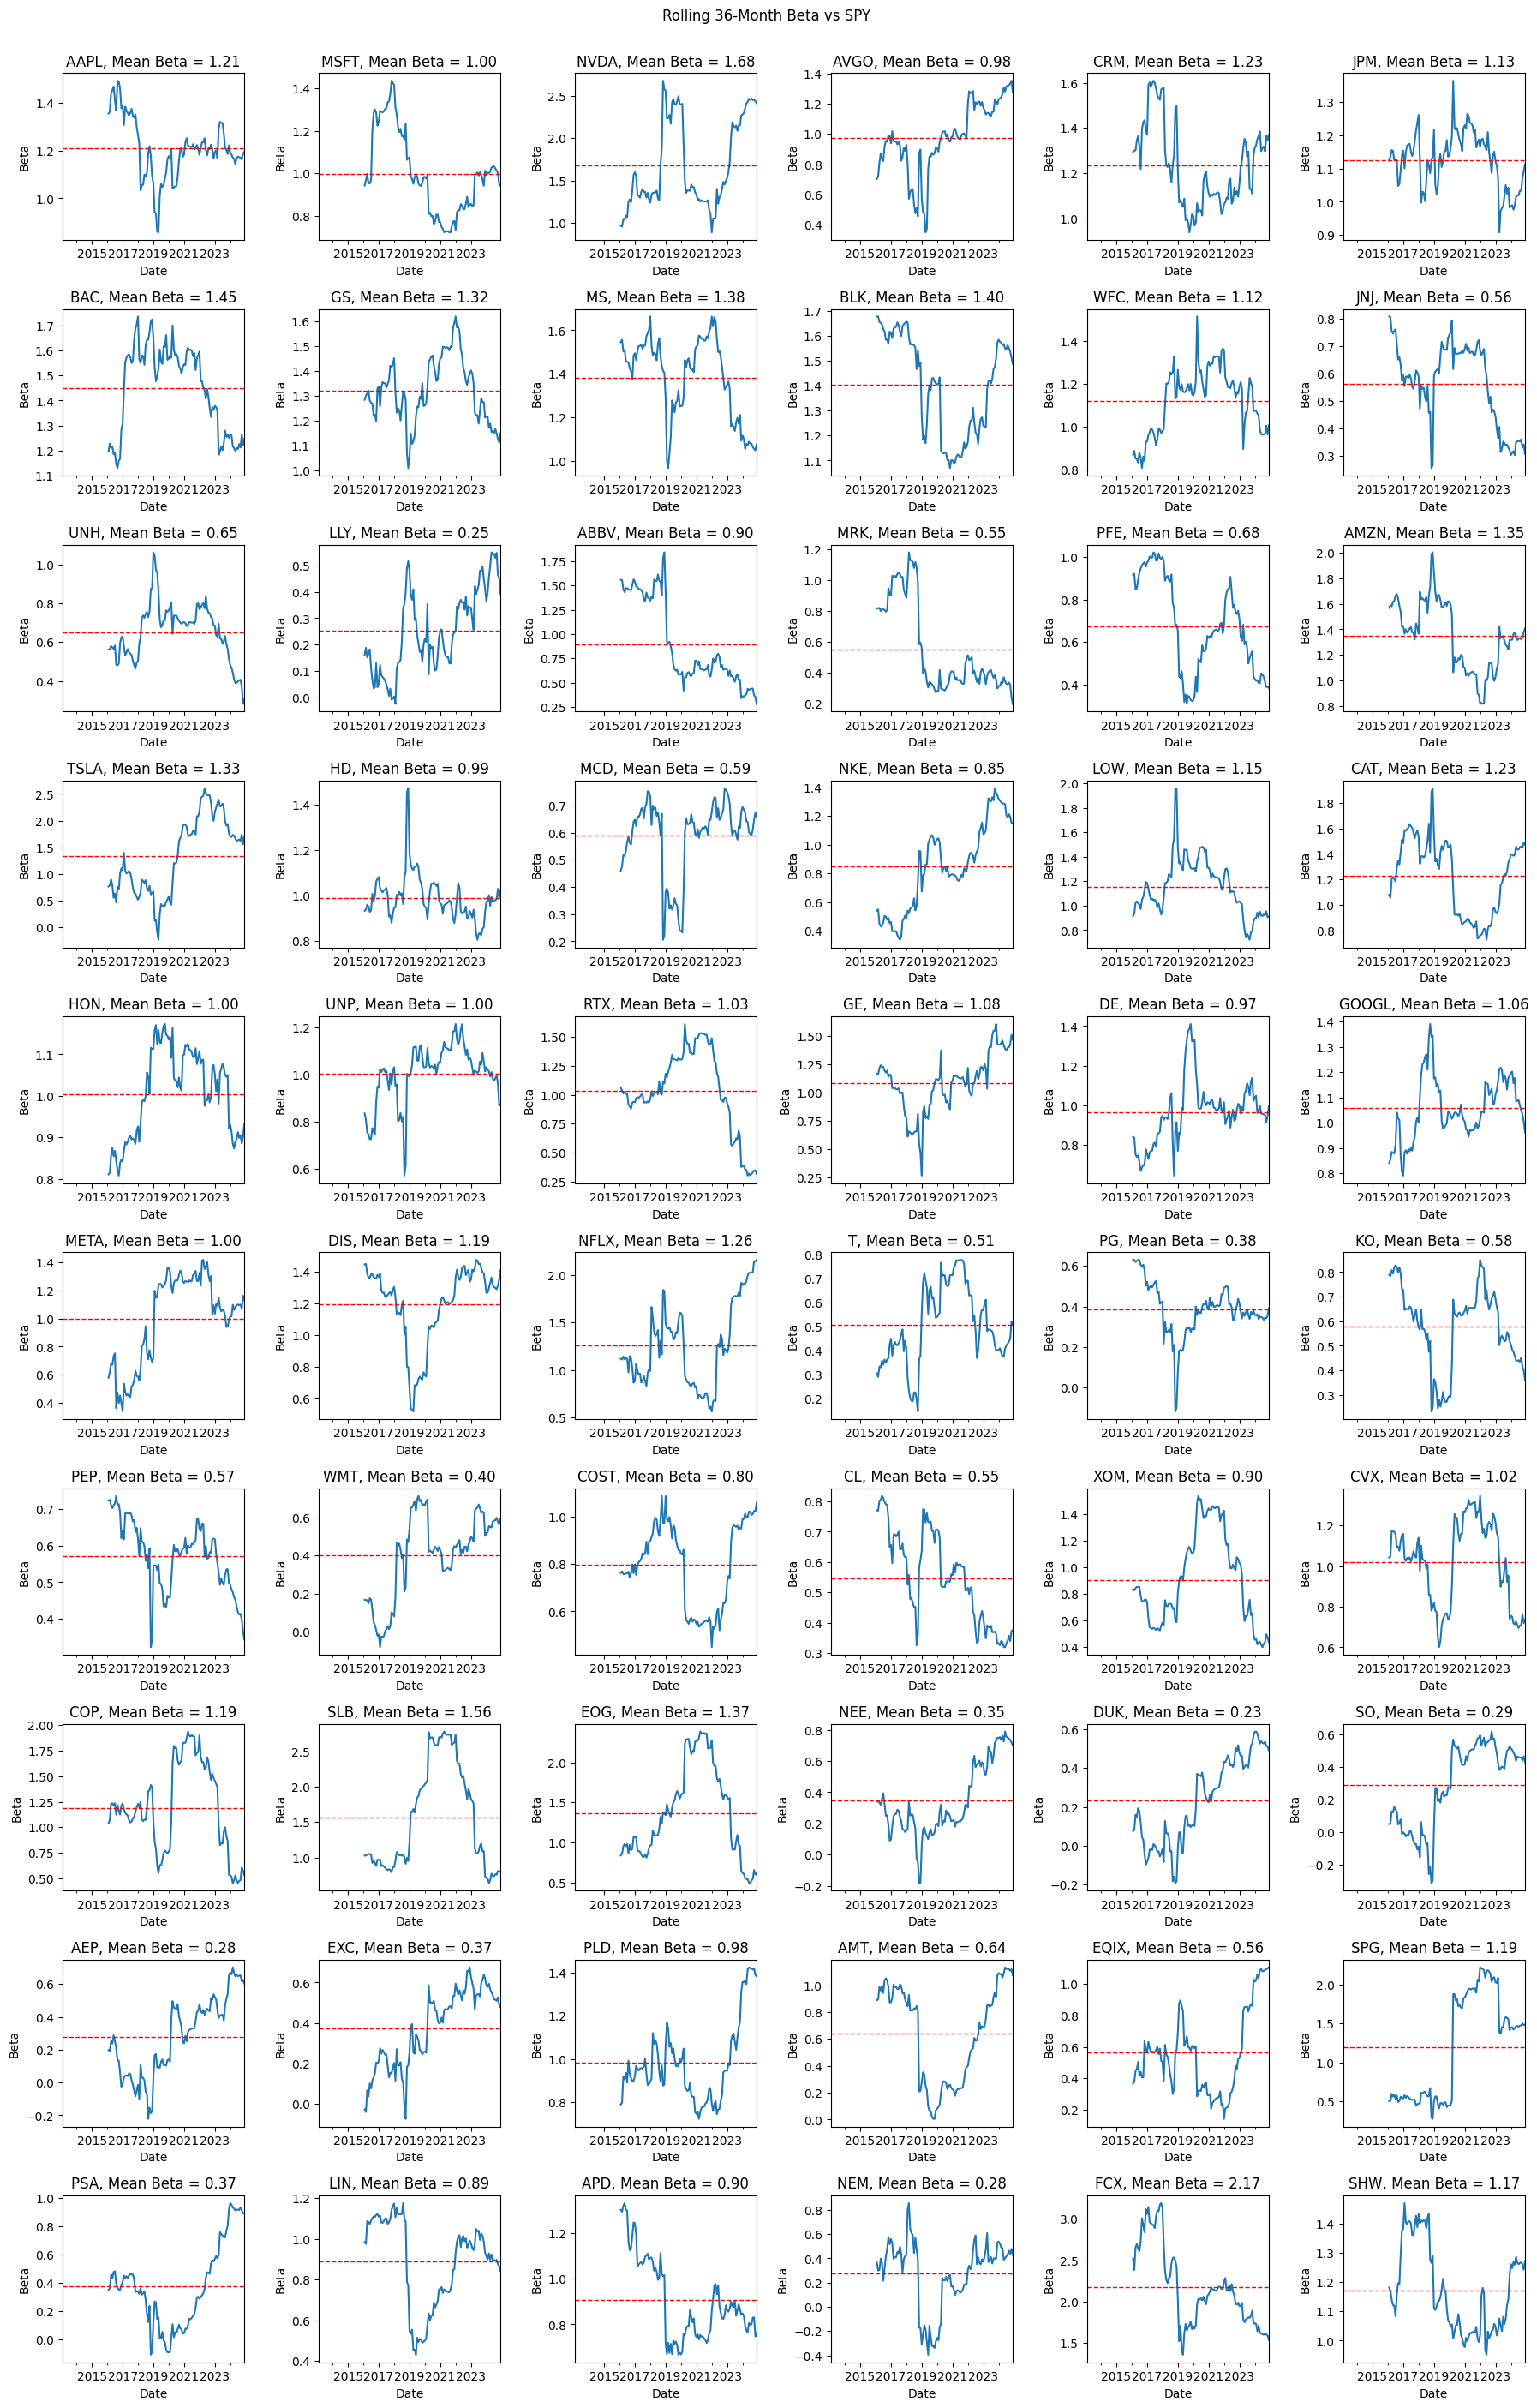

In [8]:
fig, axes = plt.subplots(10, 6, figsize=(18, 28))
axes = axes.flatten()

for i, ticker in enumerate(beta_panel.columns):
    ax = axes[i]
    beta_panel[ticker].plot(ax=ax, linewidth=1.5)
    mean_beta = beta_panel[ticker].mean()
    ax.axhline(mean_beta, color="red", ls="--", linewidth=1, label="Mean")
    ax.set_title(f"{ticker}, Mean Beta = {mean_beta:.2f}")
    ax.set_ylabel("Beta")

for j in range(len(beta_panel.columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Rolling 36-Month Beta vs SPY", y=1.002)
fig.tight_layout()
plt.savefig("outputs/beta_panel.png")
plt.show()

In [9]:
# 2. Momentum
mom_start = 12 # 12 months lookback
mom_end = 1 # exclude most recent month - noisy
momentum_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < mom_start:
        continue  # Not enough data for the first few months

    window = returns.iloc[i-mom_start:i-mom_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    momentum_panel.loc[date] = compounded

momentum_panel.to_csv("data/signal_momentum_raw.csv")
print(momentum_panel)

                AAPL      MSFT      NVDA      AVGO       CRM       JPM  \
Date                                                                     
2013-02-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-03-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-04-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-05-01       NaN       NaN       NaN       NaN       NaN       NaN   
2013-06-01       NaN       NaN       NaN       NaN       NaN       NaN   
...              ...       ...       ...       ...       ...       ...   
2024-08-01  0.051980  0.314988  1.367512  0.725579  0.082536  0.285725   
2024-09-01  0.159496  0.258990  1.123252  0.687499  0.107280  0.452157   
2024-10-01  0.315452  0.301165  1.478508  0.911243  0.188168  0.553817   
2024-11-01  0.343209  0.257860  1.694839  0.985215  0.294633  0.518054   
2024-12-01  0.176473  0.064544  1.581451  0.789113  0.123137  0.421125   

                 BAC        GS       

In [10]:
# 3. Size
size_panel = log_market_cap.copy()
size_panel = size_panel.reindex(index=monthly_index)
size_panel = size_panel.reindex(columns=all_tickers)

assert size_panel.index.equals(monthly_index), \
    "Index mismatch between size panel and returns index"

assert size_panel.columns.tolist() == all_tickers, \
    "Column mismatch between size panel and returns columns"

size_panel.to_csv("data/signal_size_raw.csv")

In [11]:
# 4. Low Volatility
vol_window = 12
low_vol_panel = -returns.rolling(window = vol_window, min_periods = 10).std() # Negative for low vol = high score
low_vol_panel = low_vol_panel.reindex(index=monthly_index)
low_vol_panel = low_vol_panel.reindex(columns=all_tickers)
low_vol_panel.to_csv("data/signal_lowvol_raw.csv")

In [12]:
# 5. Long-term Reversal
ltr_start = 36
ltr_end = 12
ltr_panel = pd.DataFrame(np.nan, index = monthly_index, columns = all_tickers)

for i, date in enumerate(monthly_index):
    if i < ltr_start:
        continue  
    
    window = returns.iloc[i-ltr_start:i-ltr_end] 
    compounded = (1 + window).prod(axis = 0, skipna = False) - 1
    ltr_panel.loc[date] = -compounded 

ltr_panel.to_csv("data/signal_ltr_raw.csv")

In [13]:
'''
dates = np.load("data/dates.npy", allow_pickle=True) 
tickers = np.load("data/tickers.npy", allow_pickle=True)  
factors = np.load("data/factors.npy", allow_pickle=True) 


data = pd.read_csv("data/prices.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("data/returns.csv", index_col=0, parse_dates=True).reindex(dates)
spy_returns = pd.read_csv("data/spy_returns.csv", index_col=0, parse_dates=True).reindex(dates)
mktcap_panel = pd.read_csv("data/market_cap.csv", index_col=0, parse_dates=True).reindex(dates)
beta_panel = pd.read_csv("data/signal_beta_raw.csv", index_col=0, parse_dates=True)
momentum_panel = pd.read_csv("data/signal_momentum_raw.csv", index_col=0, parse_dates=True)
size_panel = pd.read_csv("data/signal_size_raw.csv", index_col=0, parse_dates=True)
low_vol_panel = pd.read_csv("data/signal_lowvol_raw.csv", index_col=0, parse_dates=True)
ltr_panel = pd.read_csv("data/signal_ltr_raw.csv", index_col=0, parse_dates=True)
'''



print(beta_panel.shape)
print(momentum_panel.shape)
print(size_panel.shape)
print(low_vol_panel.shape)
print(ltr_panel.shape)

(143, 60)
(143, 60)
(143, 60)
(143, 60)
(143, 60)


In [14]:
# Winsorise, Z-score normalisation and Burn-in
# Set values < 1%ile to 1%ile, > 99%ile to 99%ile, across all stocks, at each time t - hence 'cross sectional'
def winsorise(signal_panel: pd.DataFrame, lower = 0.01, upper = 0.99) -> pd.DataFrame:
    def winsorise_row(row):
        lower_bound = row.quantile(lower)
        upper_bound = row.quantile(upper)
        return row.clip(lower=lower_bound, upper=upper_bound)
    
    return signal_panel.apply(winsorise_row, axis=1)

def normalise(signal_panel: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return signal_panel.apply(normalise_row, axis=1)

def trim_burn_in(signal_panel: pd.DataFrame, burn_in_periods = 36) -> pd.DataFrame:
    return signal_panel.iloc[burn_in_periods:]



In [15]:
signals_raw = {
    "beta": beta_panel,
    "momentum": momentum_panel,
    "size": size_panel,
    "low_vol": low_vol_panel,
    "ltr": ltr_panel
}

signals_processed = {
    name: trim_burn_in(winsorise(normalise(panel))) for name, panel in signals_raw.items() 
}

np.save("data/signals_raw.npy", signals_raw)
np.save("data/signals_processed.npy", signals_processed)

In [16]:
# Trim signals due to burn-in
for signal in signals_processed.values():
    print(signal.isna().sum().sum())
    print(signal.shape)

# No NaNs


0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)
0
(107, 60)


## 3. Orthogonalise and weights via Information Coefficient

In [18]:
def residualise(target: pd.DataFrame, controls):
    if isinstance(controls, (pd.DataFrame, pd.Series)):
        controls = [controls]
    elif isinstance(controls, tuple):
        controls = list(controls)
    elif not isinstance(controls, list):
        raise TypeError("controls must be a DataFrame, Series, list, or tuple")

    controls = [
        ctrl.reindex(index=target.index, columns=target.columns)
        if isinstance(ctrl, pd.DataFrame)
        else ctrl.reindex(index=target.index)
        for ctrl in controls
    ]

    residuals = pd.DataFrame(index=target.index, columns=target.columns, dtype=float)

    for t in target.index:
        y = target.loc[t]
        X = pd.concat(
            [ctrl.loc[t].rename(f"ctrl_{i}") for i, ctrl in enumerate(controls)],
            axis=1,
        )

        common_idx = y.index.intersection(X.index)
        y = y.reindex(common_idx)
        X = X.reindex(common_idx)

        valid = y.notna() & X.notna().all(axis=1)
        if valid.sum() < 2:
            continue

        y_clean = y.loc[valid]
        X_clean = X.loc[valid]
        X_clean = add_constant(X_clean, has_constant="add")

        try:
            model = OLS(y_clean, X_clean).fit()
            residuals.loc[t, X_clean.index] = model.resid
        except Exception:
            continue

    return residuals

# 1. Size orthogonal to beta
size_clean = residualise(signals_processed["size"], signals_processed["beta"])

# 2. low vol orthogonal to beta + size
lowvol_clean = residualise(
    signals_processed["low_vol"],
    [signals_processed["beta"], size_clean],
)

# 3. momentum orthogonal to beta + size + low vol
momentum_clean = residualise(
    signals_processed["momentum"],
    [signals_processed["beta"], size_clean, lowvol_clean],
)

# 4. ltr orthogonal to beta + size + low vol + momentum
ltr_clean = residualise(
    signals_processed["ltr"],
    [signals_processed["beta"], size_clean, lowvol_clean, momentum_clean],
)

signals_cleaned = {
    "beta": signals_processed["beta"],
    "momentum": momentum_clean,
    "size": size_clean,
    "low_vol": lowvol_clean,
    "ltr": ltr_clean
}
    
np.save("data/signals_cleaned.npy", signals_cleaned)

dates = signals_cleaned["beta"].index
factors = list(signals_cleaned.keys())




In [19]:
returns = returns.reindex(dates)

def compute_ic(name: str, signal: pd.DataFrame, returns: pd.DataFrame):
    returns = returns.shift(-1) # align r_{t+1}
    ic_series = pd.DataFrame(index = signal.index, columns = [name])
    
    for t in signal.index:
        x = signal.loc[t]
        r = returns.loc[t]

        valid = x.notna() & r.notna()

        ic = x[valid].corr(r[valid])
        ic_series.loc[t] = ic

    return ic_series



In [20]:
ic_df = pd.DataFrame(index = dates)
for name, signal in signals_processed.items():
    ic_df = pd.concat([ic_df, compute_ic(name, signal, returns)], axis = 1)
ic_df.dropna(inplace = True)
weights_rolling = normalise(ic_df).rolling(window = 24).mean().dropna()
weights_rolling

,beta,momentum,size,low_vol,ltr
Date,,,,,
2018-01-01,0.501200,0.225687,-0.006676,-0.418252,-0.301960
2018-02-01,0.413293,0.200959,-0.019438,-0.315145,-0.279668
2018-03-01,0.342287,0.234210,0.065551,-0.287326,-0.354721
2018-04-01,0.405611,0.221432,0.072377,-0.361993,-0.337426
2018-05-01,0.431392,0.163609,0.118486,-0.381853,-0.331634
...,...,...,...,...,...
2024-07-01,0.069660,0.208366,0.091209,-0.269041,-0.100193
2024-08-01,0.154105,0.120901,0.072011,-0.298656,-0.048361
2024-09-01,0.152603,0.147555,0.148881,-0.303482,-0.145557


In [21]:
t_eval = weights_rolling.index

for name, signal in signals_cleaned.items():
    signals_cleaned[name] = signal.reindex(t_eval)

signal_matrix = np.stack(
    [
        signals_cleaned["beta"].values,   
        signals_cleaned["momentum"].values,     
        signals_cleaned["size"].values,    
        signals_cleaned["low_vol"].values,   
        signals_cleaned["ltr"].values  
    ],
    axis=2   # stack along the 3rd dimension
)

signal_matrix.shape

(83, 60, 5)

In [22]:
weights = weights_rolling.to_numpy()
scores = np.sum(signal_matrix * weights[:, None, :], axis = 2)
scores = pd.DataFrame(
    scores, 
    index = t_eval, 
    columns = all_tickers
)
scores

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.285840,0.176178,2.690819,0.573815,0.510334,0.242667,0.534587,0.271502,0.434672,0.342949,...,-0.220629,0.046781,-0.026263,-0.495335,-0.569932,-0.144471,-0.188132,-0.083726,1.734082,0.390929
2018-02-01,-0.061821,0.052902,2.329174,0.287401,0.289539,0.113104,0.311829,0.076747,0.227815,0.270060,...,-0.084370,0.026850,0.277534,-0.417798,-0.625850,-0.031818,-0.141252,-0.034790,1.135195,0.279374
2018-03-01,-0.182799,0.224032,2.303033,0.096104,0.047077,0.159094,0.428464,0.000106,0.147991,0.137558,...,0.007409,-0.057913,0.385645,-0.427678,-0.547641,-0.116467,-0.269695,-0.139676,0.610690,0.110435
2018-04-01,-0.007602,0.266422,2.422983,0.083315,0.025286,0.137617,0.427578,-0.043879,0.126943,0.115498,...,-0.166125,-0.062098,0.195755,-0.523330,-0.725786,-0.156213,-0.405234,-0.148265,0.921821,0.069241
2018-05-01,0.208311,0.157760,2.088038,0.262866,-0.043197,0.024332,0.408185,-0.149352,0.041874,0.029994,...,-0.122817,-0.070256,0.163396,-0.617573,-0.835493,-0.223130,-0.523944,-0.318698,1.118045,0.084571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.064901,0.008372,0.998803,0.512507,0.079362,-0.008816,-0.027073,0.006846,0.140799,-0.173514,...,0.115084,0.065466,-0.220980,-0.106186,-0.102886,-0.225416,-0.365844,0.346354,0.192995,0.081627
2024-08-01,0.000280,0.018103,1.030570,0.470740,0.297355,-0.155432,-0.152813,-0.122658,0.161257,-0.006425,...,0.352467,0.223457,-0.093819,-0.134002,0.135671,-0.269946,-0.265981,0.384429,0.218222,0.193391
2024-09-01,0.129234,0.171201,1.283601,0.646659,0.231991,0.071232,-0.138413,-0.020036,0.145169,-0.096934,...,0.272747,0.092831,-0.212198,-0.252574,0.018061,-0.268402,-0.349925,0.305258,0.187904,0.158392


In [38]:
scores_rank = scores.rank(axis = 1, ascending = False)

scores_rank

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,14.0,18.0,1.0,5.0,8.0,16.0,7.0,15.0,10.0,13.0,...,40.0,23.0,26.0,47.0,48.0,33.0,36.0,29.0,2.0,12.0
2018-02-01,31.0,23.0,1.0,11.0,10.0,19.0,9.0,21.0,15.0,14.0,...,33.0,26.0,13.0,45.0,56.0,28.0,37.0,29.0,3.0,12.0
2018-03-01,38.0,13.0,1.0,21.0,24.0,15.0,6.0,26.0,16.0,17.0,...,25.0,30.0,7.0,49.0,56.0,35.0,43.0,37.0,5.0,20.0
2018-04-01,26.0,11.0,1.0,20.0,24.0,17.0,7.0,28.0,18.0,19.0,...,37.0,29.0,14.0,52.0,59.0,34.0,47.0,33.0,4.0,22.0
2018-05-01,15.0,18.0,1.0,13.0,29.0,25.0,11.0,33.0,23.0,24.0,...,32.0,31.0,17.0,52.0,59.0,40.0,49.0,45.0,4.0,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,32.0,24.0,1.0,3.0,20.0,27.0,28.0,26.0,15.0,40.0,...,16.0,22.0,46.0,35.0,34.0,47.0,59.0,7.0,11.0,19.0
2024-08-01,25.0,22.0,1.0,4.0,10.0,42.0,41.0,37.0,16.0,26.0,...,8.0,12.0,33.0,39.0,18.0,51.0,50.0,5.0,13.0,15.0
2024-09-01,18.0,14.0,1.0,3.0,11.0,24.0,38.0,31.0,16.0,35.0,...,8.0,22.0,42.0,44.0,29.0,46.0,52.0,7.0,13.0,15.0


## 4. Evaluate Portfolio

In [ ]:
# Long top 20%, Short bottom 20%